In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np

from delphi.utils.helpers import logistic
from delphi.grad import TruncatedBCE

In [2]:
def trunc_logistic_mle(pred, targ, phi, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    pred.requires_grad = True
    loss = TruncatedBCE.apply(pred, targ, phi)
    loss = loss.sum(0)
    loss.backward()
    return loss, pred.grad

# Untruncated Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression

W = .5*ch.ones(1, 1)
print(f'groud truth W:\n {W}')

X = ch.rand(5000, 1)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W + logistic.sample([X.size(0), 1])

Y = (Z >= 0).int()


log_reg = LogisticRegression(penalty=None, fit_intercept=False)
log_reg.fit(X, Y)


gt_w = ch.from_numpy(log_reg.coef_)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[0.5000]])
ground truth num samples: 5000
fitted w: tensor([[0.4816]], dtype=torch.float64)


/home/patroklos/base/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [42]:
def phi(z): 
    return ch.ones_like(z)

trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices], Z[trunc_indices]
Y_trunc = Y[trunc_indices]
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None,fit_intercept=False)
trunc_log_reg.fit(X_trunc, Y_trunc)

trunc_w = ch.from_numpy(trunc_log_reg.coef_)

print(f'trunc fitted w: {trunc_w}')

alpha: 1.0
trunc fitted w: tensor([[0.4816]], dtype=torch.float64)


/home/patroklos/base/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


<IPython.core.display.Javascript object>


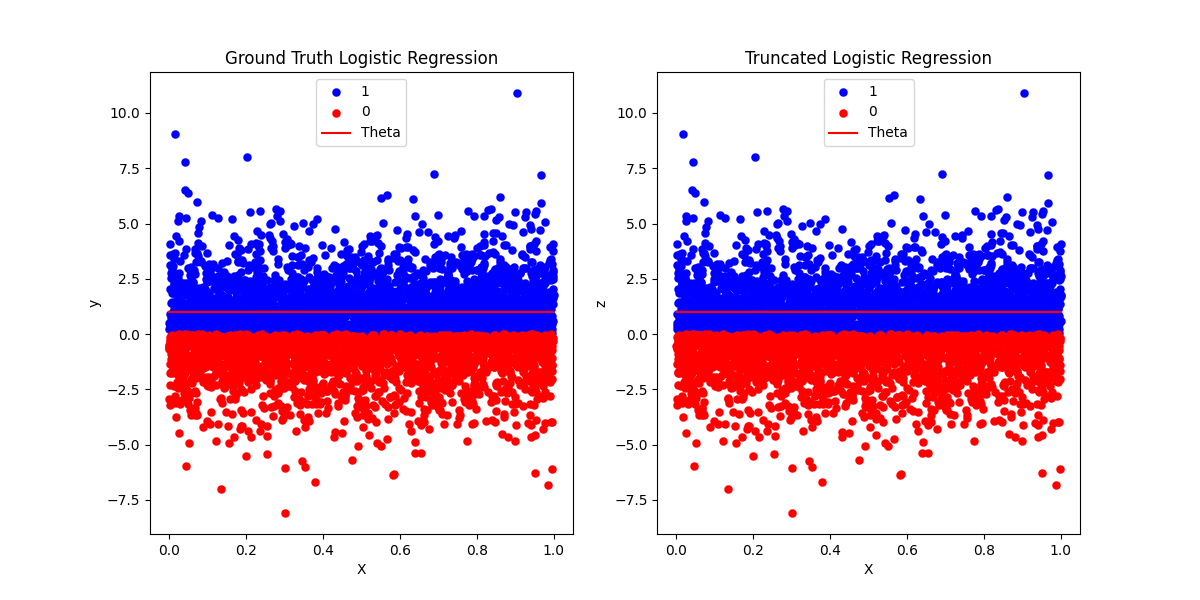

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ones = Y.flatten().nonzero()
zeros = (~Y.bool().flatten()).nonzero()
ax1.scatter(X[ones], Z[ones], linewidths=.1, color='blue', label='1')
ax1.scatter(X[zeros], Z[zeros], linewidths=.1, color='red', label='0')
X_sorted = X.sort()[0]
pred = log_reg.predict(X_sorted)
ax1.plot(X_sorted, pred, color='red', label='Theta')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Ground Truth Logistic Regression')
ax1.legend()

trunc_ones = Y_trunc.flatten().nonzero()
trunc_zeros = (~Y_trunc.bool().flatten()).nonzero()
ax2.scatter(X_trunc[trunc_ones], Z_trunc[trunc_ones], linewidths=.1, color='blue', label='1')
ax2.scatter(X_trunc[trunc_zeros], Z_trunc[trunc_zeros], linewidths=.1, color='red', label='0')
trunc_pred = trunc_log_reg.predict(X_sorted)
ax2.plot(X_sorted, trunc_pred, color='red', label='Theta')
ax2.set_xlabel('X')
ax2.set_ylabel('z')
ax2.set_title('Truncated Logistic Regression')
ax2.legend()
plt.show()

# Vary w

In [12]:
from torch.nn import BCEWithLogitsLoss

In [13]:
bce = BCEWithLogitsLoss()


ws = ch.linspace(-3, 5, 35)

losses = ch.Tensor([])
grads = ch.Tensor([])

bce_losses = ch.Tensor([])
bce_grads = ch.Tensor([])

for w in ws: 
    pred = X_trunc@w.reshape(1, 1)
    pred.requires_grad = True
    loss_bce = bce(pred, Y_trunc.float())
    loss_bce.backward()
    bce_losses = ch.cat([bce_losses, loss_bce[...,None].detach()])
    bce_grads = ch.cat([bce_grads, (pred.grad * X_trunc).sum(0)])
    
    loss, pred_grad = trunc_logistic_mle(X_trunc @ w.reshape(1, 1), Y_trunc, phi)
    losses = ch.cat([losses, loss[...,None].detach()])
    grads = ch.cat([grads, (pred_grad * X_trunc).sum(0)])

<IPython.core.display.Javascript object>


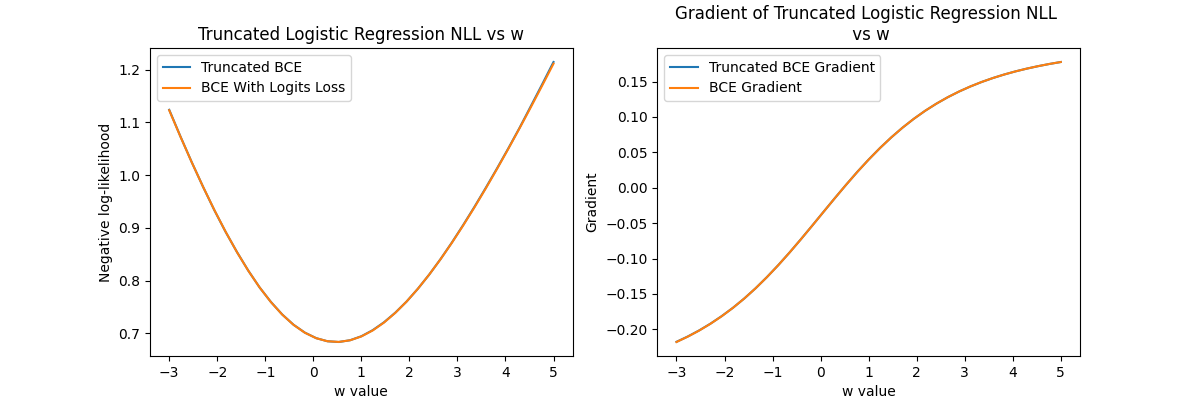

In [14]:
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ws, losses, label="Truncated BCE")
ax1.plot(ws, bce_losses, label="BCE With Logits Loss")

ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w")
ax1.legend()

ax2.plot(ws, grads, label="Truncated BCE Gradient")
ax2.plot(ws, bce_grads, label="BCE Gradient")

ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Logistic Regression NLL \n vs w")
ax2.legend()

plt.show()

In [15]:
print(f'ws: {ws}')
print(f'bce with logit losses: {bce_losses}')
print(f'truncated bce losses: {losses.flatten()}')

ws: tensor([-3.0000, -2.7647, -2.5294, -2.2941, -2.0588, -1.8235, -1.5882, -1.3529,
        -1.1176, -0.8824, -0.6471, -0.4118, -0.1765,  0.0588,  0.2941,  0.5294,
         0.7647,  1.0000,  1.2353,  1.4706,  1.7059,  1.9412,  2.1765,  2.4118,
         2.6471,  2.8824,  3.1176,  3.3529,  3.5882,  3.8235,  4.0588,  4.2941,
         4.5294,  4.7647,  5.0000])
bce with logit losses: tensor([1.1229, 1.0725, 1.0240, 0.9776, 0.9336, 0.8922, 0.8538, 0.8187, 0.7871,
        0.7593, 0.7357, 0.7163, 0.7014, 0.6910, 0.6852, 0.6839, 0.6870, 0.6943,
        0.7056, 0.7206, 0.7389, 0.7604, 0.7846, 0.8114, 0.8405, 0.8715, 0.9043,
        0.9387, 0.9745, 1.0116, 1.0498, 1.0889, 1.1289, 1.1697, 1.2111])
truncated bce losses: tensor([1.1237, 1.0729, 1.0241, 0.9776, 0.9332, 0.8920, 0.8540, 0.8189, 0.7871,
        0.7596, 0.7359, 0.7165, 0.7015, 0.6911, 0.6852, 0.6838, 0.6871, 0.6947,
        0.7061, 0.7211, 0.7393, 0.7604, 0.7846, 0.8114, 0.8407, 0.8720, 0.9051,
        0.9396, 0.9756, 1.0126, 1.0505, 1.

In [16]:
ws[losses.argmin()], grads[losses.argmin()]

(tensor(0.5294), tensor(0.0040))

# Truncated Logistic Regression without Bias

In [43]:
def phi(z): 
    return z > -.5

trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices], Z[trunc_indices]
Y_trunc = Y[trunc_indices]
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None, fit_intercept=False)
trunc_log_reg.fit(X_trunc, Y_trunc)

trunc_w = ch.from_numpy(trunc_log_reg.coef_)

print(f'trunc fitted w: {trunc_w}')

alpha: 0.6696
trunc fitted w: tensor([[2.5820]], dtype=torch.float64)


/home/patroklos/base/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


<IPython.core.display.Javascript object>


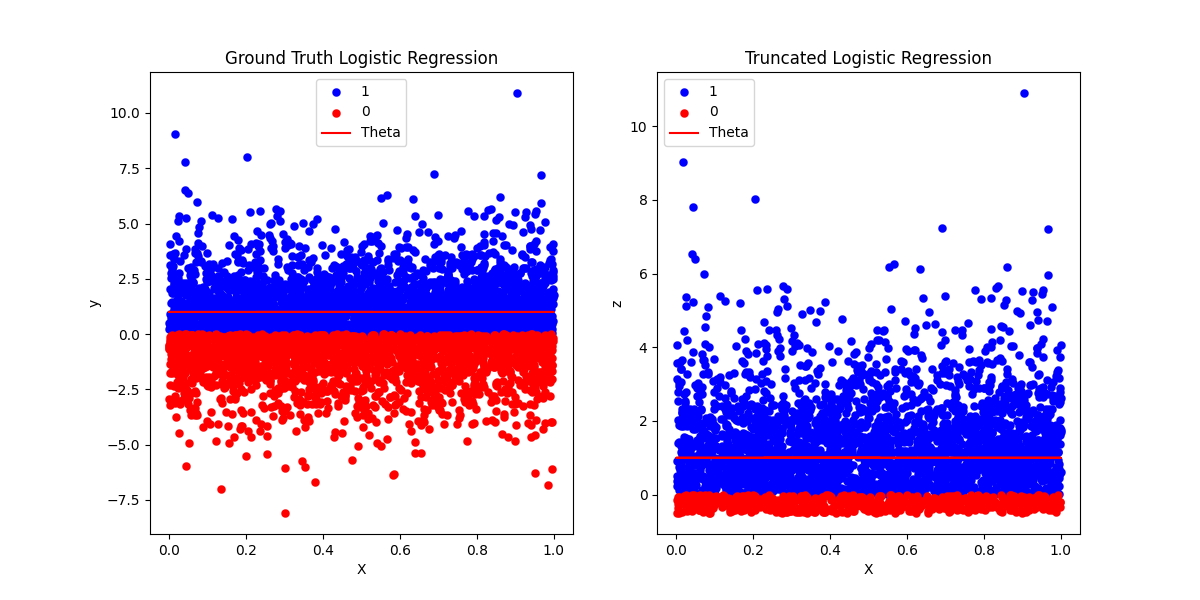

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ones = Y.flatten().nonzero()
zeros = (~Y.bool().flatten()).nonzero()
ax1.scatter(X[ones], Z[ones], linewidths=.1, color='blue', label='1')
ax1.scatter(X[zeros], Z[zeros], linewidths=.1, color='red', label='0')
X_sorted = X.sort()[0]
pred = log_reg.predict(X_sorted)
ax1.plot(X_sorted, pred, color='red', label='Theta')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Ground Truth Logistic Regression')
ax1.legend()

trunc_ones = Y_trunc.flatten().nonzero()
trunc_zeros = (~Y_trunc.bool().flatten()).nonzero()
ax2.scatter(X_trunc[trunc_ones], Z_trunc[trunc_ones], linewidths=.1, color='blue', label='1')
ax2.scatter(X_trunc[trunc_zeros], Z_trunc[trunc_zeros], linewidths=.1, color='red', label='0')
trunc_pred = trunc_log_reg.predict(X_sorted)
ax2.plot(X_sorted, trunc_pred, color='red', label='Theta')
ax2.set_xlabel('X')
ax2.set_ylabel('z')
ax2.set_title('Truncated Logistic Regression')
ax2.legend()
plt.show()

In [21]:
bce = BCEWithLogitsLoss()


ws = ch.linspace(-3, 5, 35)

losses = ch.Tensor([])
grads = ch.Tensor([])

bce_losses = ch.Tensor([])
bce_grads = ch.Tensor([])

for w in ws: 
    pred = X_trunc@w.reshape(1, 1)
    pred.requires_grad = True
    loss_bce = bce(pred, Y_trunc.float())
    loss_bce.backward()
    bce_losses = ch.cat([bce_losses, loss_bce[...,None].detach()])
    bce_grads = ch.cat([bce_grads, (pred.grad * X_trunc).sum(0)])
    
    loss, pred_grad = trunc_logistic_mle(X_trunc @ w.reshape(1, 1), Y_trunc, phi)
    losses = ch.cat([losses, loss[...,None].detach()])
    grads = ch.cat([grads, (pred_grad * X_trunc).sum(0)])

<IPython.core.display.Javascript object>


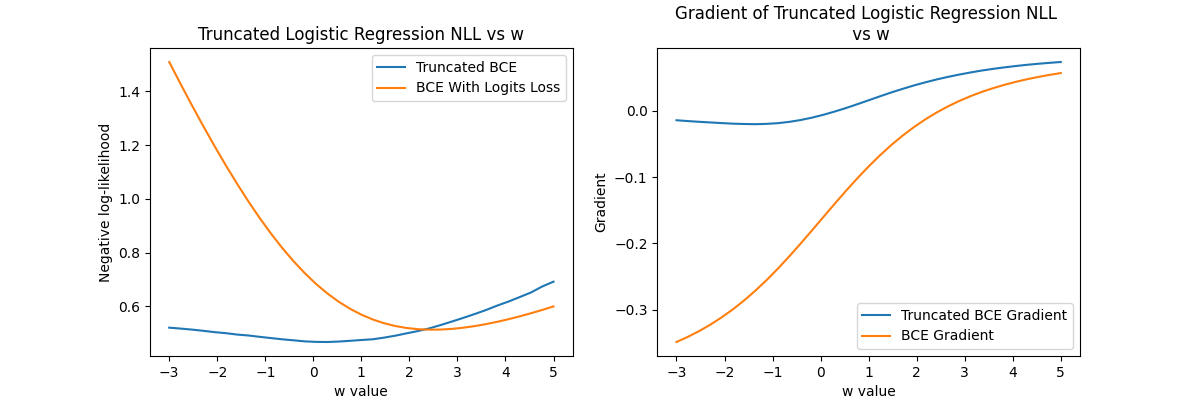

In [23]:
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ws, losses, label="Truncated BCE")
ax1.plot(ws, bce_losses, label="BCE With Logits Loss")

ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w")
ax1.legend()

ax2.plot(ws, grads, label="Truncated BCE Gradient")
ax2.plot(ws, bce_grads, label="BCE Gradient")

ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Logistic Regression NLL \n vs w")
ax2.legend()

plt.show()

# Truncated Logistic Regression with Bias

In [30]:
from statsmodels.tools.tools import add_constant

W = .5*ch.ones(1, 1)
W0 = .5*ch.ones(1, 1)
print(f'groud truth W:\n {W}')
print(f'ground truth bias:\n {W0}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W + W0 + logistic.sample([X.size(0), 1])

Y = (Z > 0).int()

gt_log_reg = LogisticRegression(penalty=None, fit_intercept=True)
gt_log_reg.fit(X, Y)

gt_w = ch.from_numpy(np.concatenate([gt_log_reg.coef_.flatten(), gt_log_reg.intercept_]))

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[0.5000]])
ground truth bias:
 tensor([[0.5000]])
ground truth num samples: 1000
fitted w: tensor([0.6028, 0.3937], dtype=torch.float64)


/home/patroklos/base/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [31]:
def phi(z): 
    return z > -.25

trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices].float(), Z[trunc_indices]
Y_trunc = (Z_trunc > 0).int()
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None, fit_intercept=True)
trunc_log_reg.fit(X_trunc, Y_trunc.flatten())

trunc_w = ch.from_numpy(np.concatenate([trunc_log_reg.coef_.flatten(), trunc_log_reg.intercept_]))

print(f'trunc fitted w: {trunc_w}')

alpha: 0.719
trunc fitted w: tensor([0.3651, 2.3138], dtype=torch.float64)


In [32]:
X_trunc_ones = ch.cat([X_trunc, ch.ones(X_trunc.size(0), 1)], dim=1)

# === Parameter grids ===
W_values = ch.linspace(-.5, 1.0, 30)
W0_values = ch.linspace(-.5, 1.5, 30)
W_, W0_ = ch.meshgrid(W_values, W0_values)

# === Compute NLL over the grid ===
Z = np.zeros_like(W_)
GRAD_W = ch.zeros_like(W_)
GRAD_W0 = ch.zeros_like(W0_)
for i in range(len(W_values)):
    for j in range(len(W0_values)):
        w, w0 = W_[i, j].reshape(1, 1), W0_[i, j].reshape(1, 1)
        trunc_pred = X_trunc @ w + w0
        loss, pred_grad = trunc_logistic_mle(trunc_pred, Y_trunc, phi)
    
        grad_ = (pred_grad * X_trunc_ones).sum(0)

        Z[i, j] = loss
        GRAD_W[i, j] = grad_[0]
        GRAD_W0[i, j] = grad_[1]
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W_min, W0_min = W_[min_idx], W0_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w={gt_w[0].item():.3f}, w0={gt_w[1].item():.3f}")
print(f"Minimum found: w={W_min:.3f}, w0={W0_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_logistic_mle((X_trunc_ones @ gt_w[...,None].float()), Y_trunc, phi)[0].item()

print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

Ground truth: w=0.603, w0=0.394
Minimum found: w=0.379, w0=0.534, loss=0.268

Loss at ground truth: 0.269
Loss at minimum: 0.268
Difference: 0.001


<IPython.core.display.Javascript object>


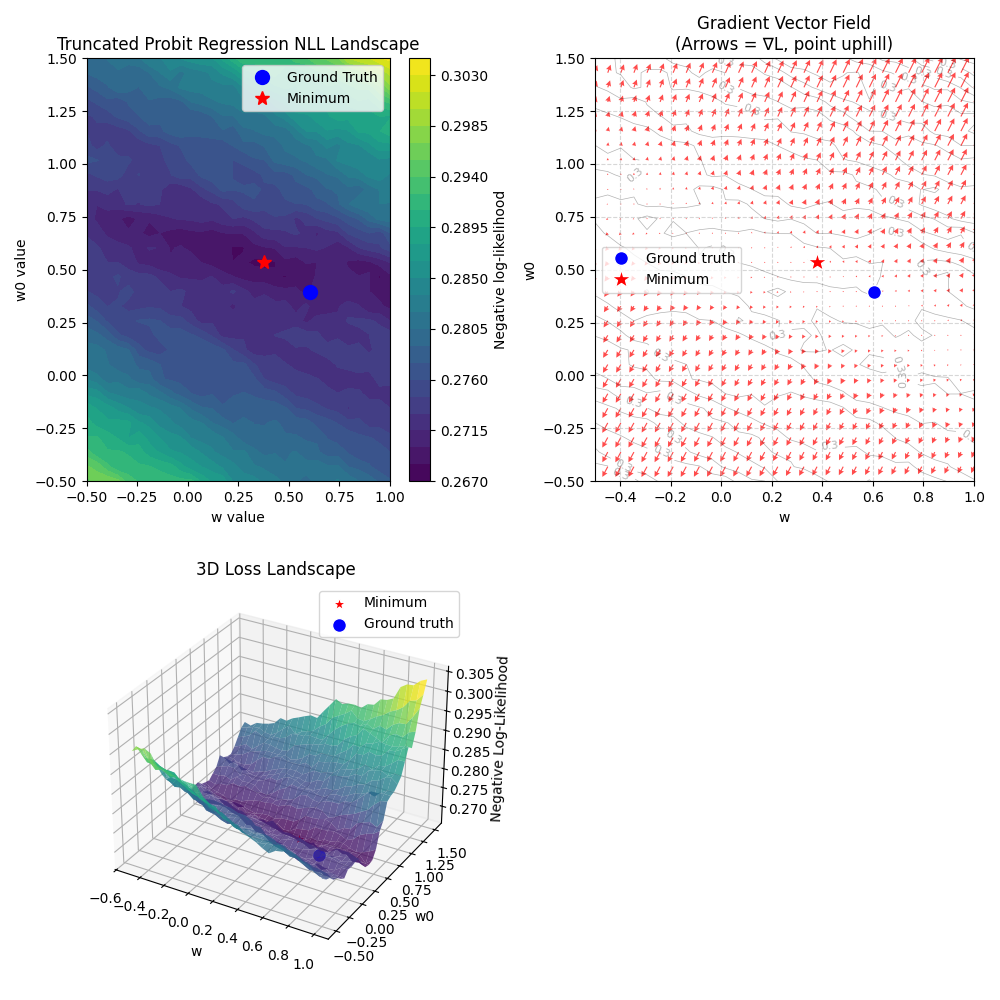

In [33]:
# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W_, W0_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Probit Regression NLL Landscape")
ax1.set_xlabel("w value")
ax1.set_ylabel("w0 value")

# mark the ground truth
ax1.plot(gt_w[0], gt_w[1], 'bo', markersize=10, label="Ground Truth")
ax1.plot(W_min.item(), W0_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W_, W0_, GRAD_W, GRAD_W0,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W_, W0_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(gt_w[0], gt_w[1], 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W_min, W0_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w')
ax4.set_ylabel('w0')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W_, W0_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W_min], [W0_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([gt_w[0]], [gt_w[1]], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w')
ax3.set_ylabel('w0')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

In [34]:
import torch.nn.functional as F

In [35]:
r = gt_w[None,...]
trunc_r = trunc_w[None,...]
trunc_cosine = F.cosine_similarity(r, trunc_r)
print(f'trunc cosine similarity: {trunc_cosine}')
w_min = ch.cat([W_min[None,...], W0_min[None,...]])[None,...]
delphi_cosine = F.cosine_similarity(r, w_min)
print(f'delphi cosine similarity: {delphi_cosine}')

trunc cosine similarity: tensor([0.6706], dtype=torch.float64)
delphi cosine similarity: tensor([0.9305], dtype=torch.float64)


# Truncated Logistic Regression with Two Weight and No Bias

In [44]:
W = ch.ones(2, 1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 2)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W + logistic.sample([X.size(0), 1])

Y = (Z > 0).int()

gt_log_reg = LogisticRegression(penalty=None, fit_intercept=False)
gt_log_reg.fit(X, Y.flatten())

gt_w = ch.from_numpy(gt_log_reg.coef_)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[1.],
        [1.]])
ground truth num samples: 1000
fitted w: tensor([[1.0458, 0.9989]], dtype=torch.float64)


In [45]:
def phi(z): 
    return z > -.25

trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices].float(), Z[trunc_indices]
Y_trunc = (Z_trunc > 0).int()
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None, fit_intercept=False)
trunc_log_reg.fit(X_trunc, Y_trunc.flatten())

trunc_w = ch.from_numpy(trunc_log_reg.coef_)

print(f'trunc fitted w: {trunc_w}')

alpha: 0.766
trunc fitted w: tensor([[3.1101, 2.4155]], dtype=torch.float64)


In [38]:
# === Parameter grids ===
W1_values = ch.linspace(-1, 1.5, 20)
W2_values = ch.linspace(-1, 1.5, 20)
W1_, W2_ = ch.meshgrid(W1_values, W2_values)

# === Compute NLL over the grid ===
Z = np.zeros_like(W1_)
GRAD_W1 = ch.zeros_like(W1_)
GRAD_W2 = ch.zeros_like(W2_)
for i in range(len(W1_values)):
    for j in range(len(W2_values)):
        w = ch.cat([W1_[i, j][...,None], W2_[i, j][...,None]])[...,None]
        trunc_pred = X_trunc @ w
        loss, pred_grad = trunc_logistic_mle(trunc_pred, Y_trunc, phi)
    
        grad_ = (pred_grad * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_W1[i, j] = grad_[0]
        GRAD_W2[i, j] = grad_[1]
    
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
W1_min, W2_min = W1_[min_idx], W2_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: w1={gt_w[:,0].item():.3f}, w2={gt_w[:,1].item():.3f}")
print(f"Minimum found: w1={W1_min:.3f}, w2={W2_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_logistic_mle((X_trunc @ gt_w.float().T), Y_trunc, phi)[0].item()

print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

Ground truth: w1=0.991, w2=0.858
Minimum found: w1=1.368, w2=0.974, loss=0.182

Loss at ground truth: 0.184
Loss at minimum: 0.182
Difference: 0.001


<IPython.core.display.Javascript object>


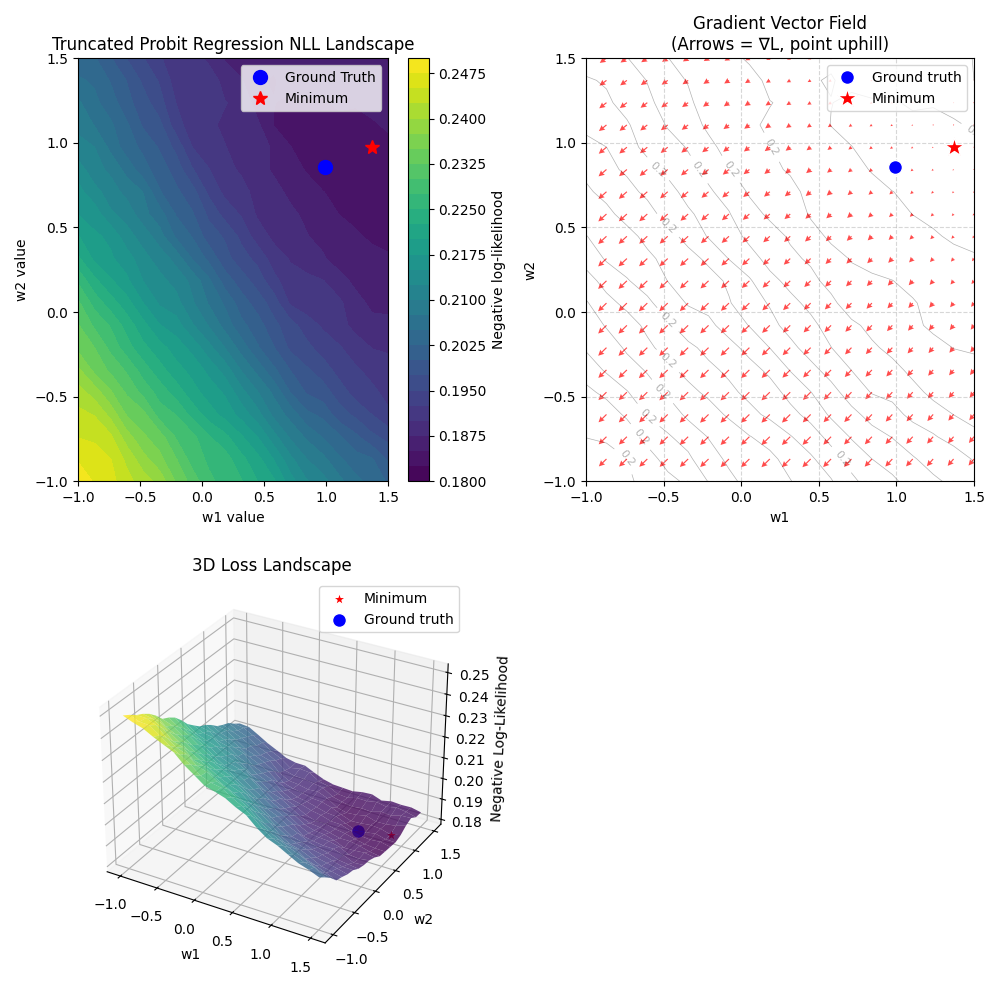

In [39]:
# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)

cp = ax1.contourf(W1_, W2_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Probit Regression NLL Landscape")
ax1.set_xlabel("w1 value")
ax1.set_ylabel("w2 value")

# mark the ground truth
ax1.plot(gt_w[:,0], gt_w[:,1], 'bo', markersize=10, label="Ground Truth")
ax1.plot(W1_min.item(), W2_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(222)

# Plot quiver
Q = ax4.quiver(W1_, W2_, GRAD_W1, GRAD_W2,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(W1_, W2_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(gt_w[:,0], gt_w[:,1], 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(W1_min, W2_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('w1')
ax4.set_ylabel('w2')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(223, projection='3d')
surf = ax3.plot_surface(W1_, W2_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([W1_min], [W2_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([gt_w[:,0]], [gt_w[:,1]], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('w1')
ax3.set_ylabel('w2')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

In [40]:
r = gt_w
trunc_r = trunc_w
trunc_cosine = F.cosine_similarity(r, trunc_r)
print(f'trunc cosine similarity: {trunc_cosine}')
w_min = ch.cat([W_min[None,...], W0_min[None,...]])[None,...]
delphi_cosine = F.cosine_similarity(r, w_min)
print(f'delphi cosine similarity: {delphi_cosine}')

trunc cosine similarity: tensor([0.9997], dtype=torch.float64)
delphi cosine similarity: tensor([0.9713], dtype=torch.float64)


(tensor([[1.0368, 0.8883]], dtype=torch.float64),
 tensor([[2.4397, 2.6306]], dtype=torch.float64))